# Sensitivity heatmap

Create technology-input sensitivity heatmaps from the reusable deterministic sensitivity helpers in `src/`. The notebook can calculate either total NPV sensitivity or specific NPV sensitivity and displays figures inline by default. Saving CSV and PNG outputs is optional.

In [1]:
from datetime import date
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from sensitivity_analysis import METRIC_SPECIFIC, METRIC_TOTAL
from sensitivity_deep_dive import (
    build_sensitivity_heatmap_figure,
    plot_sensitivity_heatmap,
    standardized_sensitivity,
)

pd.options.display.float_format = "{:,.3f}".format

## Settings

Change `NPV_METRIC` to switch between total NPV and specific NPV. The heatmap values are normalized within each technology row, so 100 marks the largest absolute NPV impact for that technology.

In [2]:
VARIATION_FRACTION = 0.20
NPV_METRIC = METRIC_SPECIFIC  # METRIC_SPECIFIC or METRIC_TOTAL
SECTORS = ("cement", "electricity")
SAVE_OUTPUTS = False

if NPV_METRIC not in (METRIC_SPECIFIC, METRIC_TOTAL):
    raise ValueError("NPV_METRIC must be METRIC_SPECIFIC or METRIC_TOTAL.")

unknown_sectors = set(SECTORS) - {"cement", "electricity"}
if unknown_sectors:
    raise ValueError(f"Unknown sectors: {sorted(unknown_sectors)}")

print(f"Selected NPV metric: {NPV_METRIC}")
print(f"Sensitivity variation: +/- {VARIATION_FRACTION:.0%}")
print(f"Sectors: {', '.join(SECTORS)}")

Selected NPV metric: specific
Sensitivity variation: +/- 20%
Sectors: cement, electricity


## Calculate sensitivity values

In [3]:
sensitivity = pd.concat(
    [
        standardized_sensitivity(
            sector=sector,
            variation_fraction=VARIATION_FRACTION,
            metric=NPV_METRIC,
        )
        for sector in SECTORS
    ],
    ignore_index=True,
)

summary_columns = [
    "sector",
    "technology",
    "metric",
    "parameter",
    "base_metric_value",
    "max_abs_impact",
    "relative_impact_percent",
    "rank",
]
display(sensitivity.loc[:, summary_columns].sort_values(["sector", "technology", "rank"]))

,sector,technology,metric,parameter,base_metric_value,max_abs_impact,relative_impact_percent,rank
44,cement,alternative_fuels,specific,Discount rate,19.211,3.933,100.000,1
45,cement,alternative_fuels,specific,Direct emissions,19.211,3.689,93.797,2
46,cement,alternative_fuels,specific,Carbon price,19.211,3.689,93.797,2
47,cement,alternative_fuels,specific,Lifetime,19.211,2.230,56.691,4
48,cement,alternative_fuels,specific,Investment cost,19.211,1.288,32.747,5
...,...,...,...,...,...,...,...,...
164,electricity,wind_onshore,specific,Variable OPEX,6.113,0.598,7.697,6
165,electricity,wind_onshore,specific,Fuel use,6.113,0.000,0.000,7
166,electricity,wind_onshore,specific,Fuel price,6.113,0.000,0.000,7
167,electricity,wind_onshore,specific,Direct emissions,6.113,0.000,0.000,7


## Heatmaps

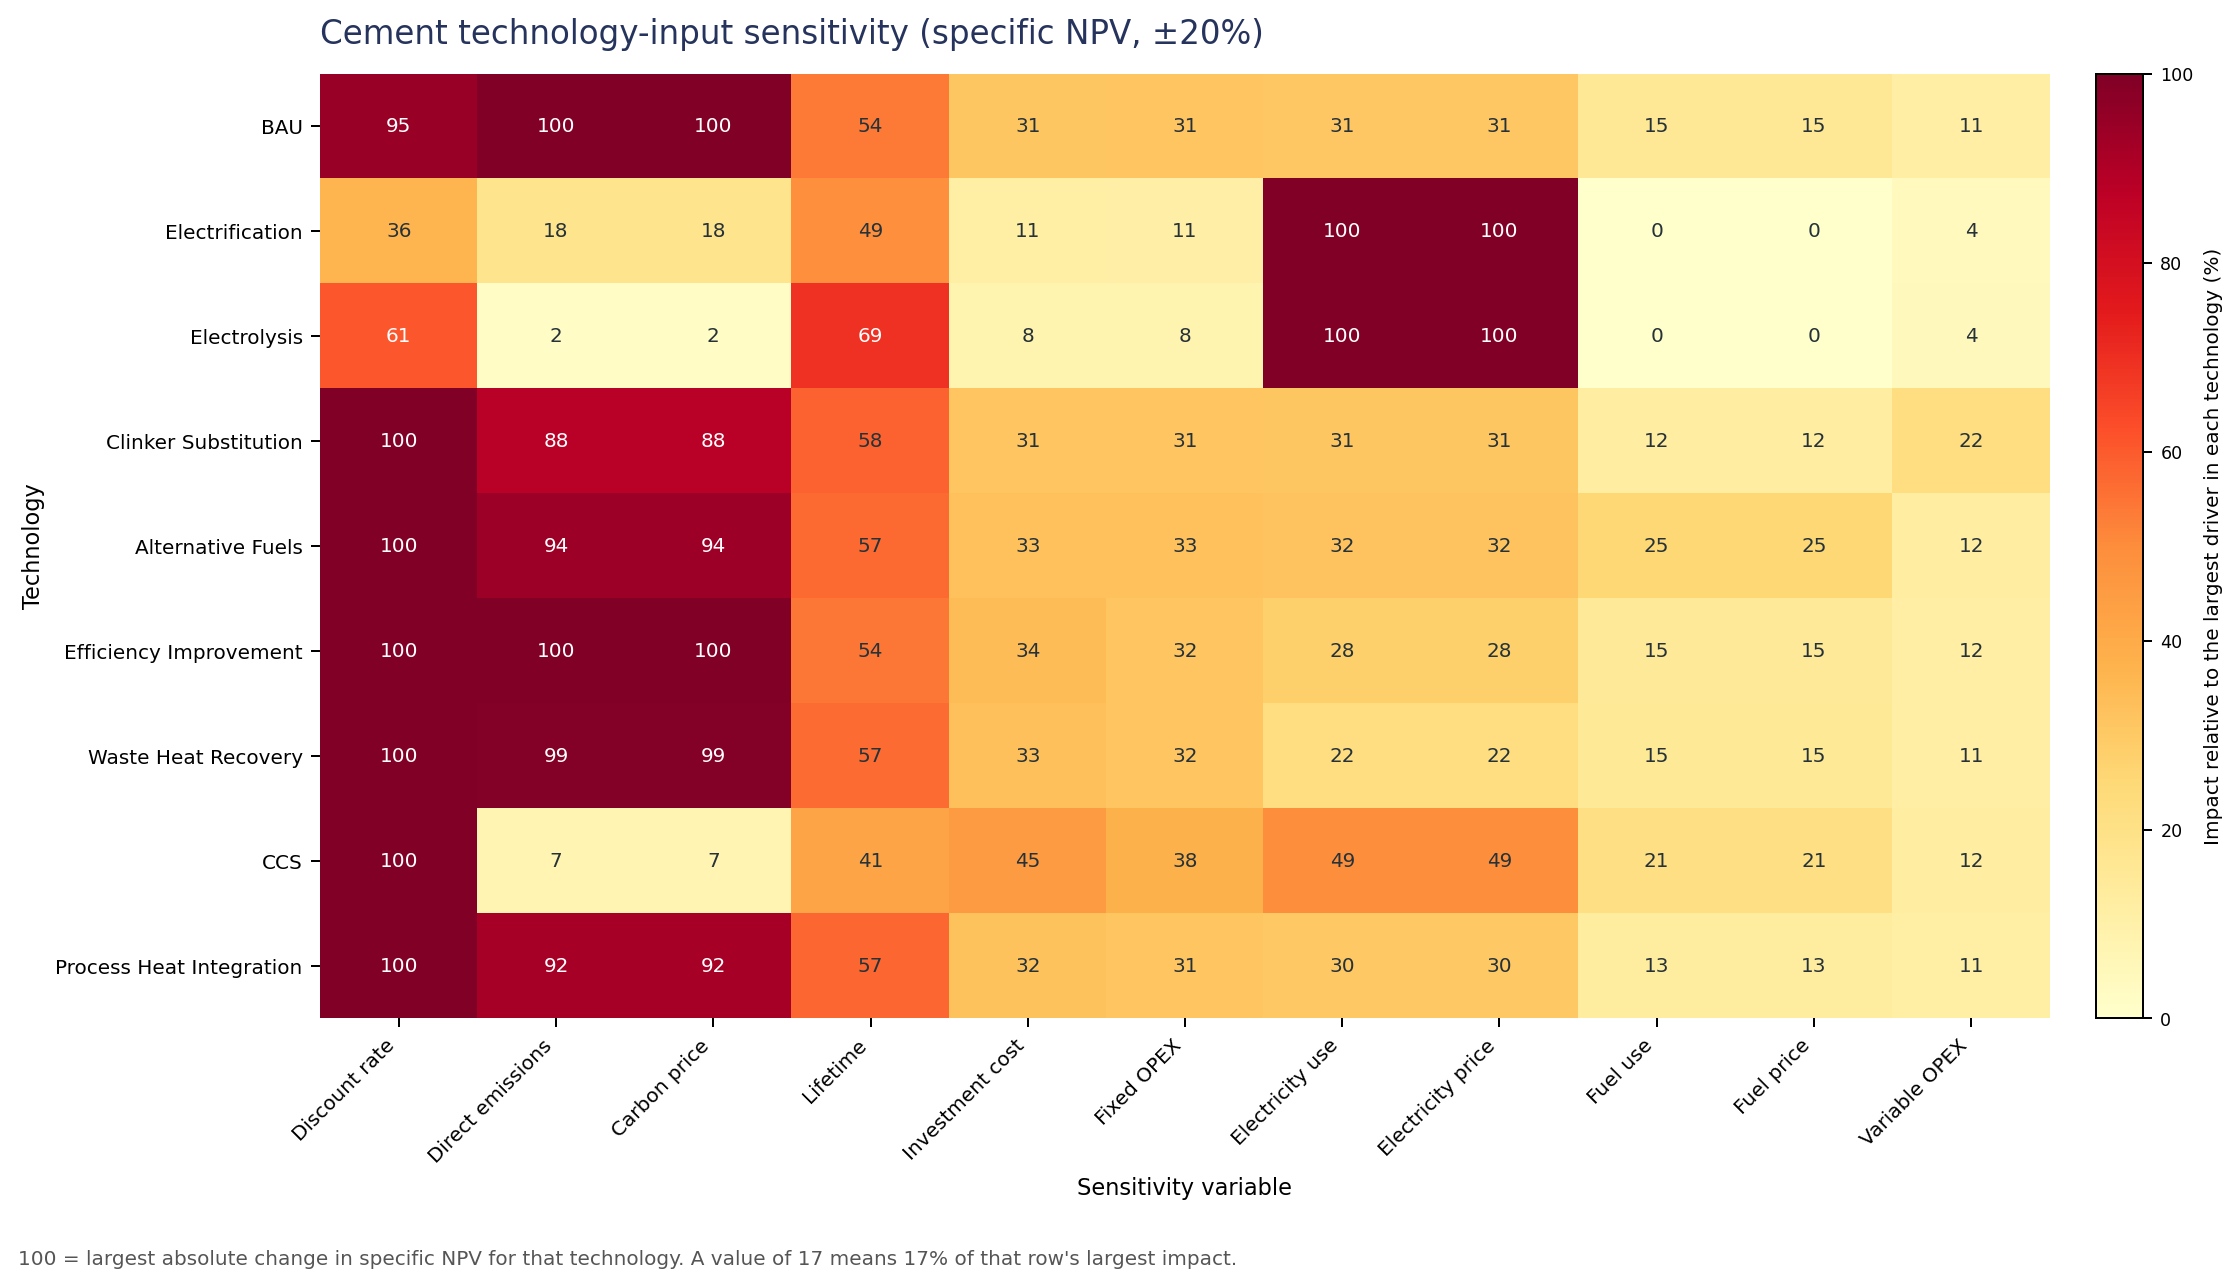

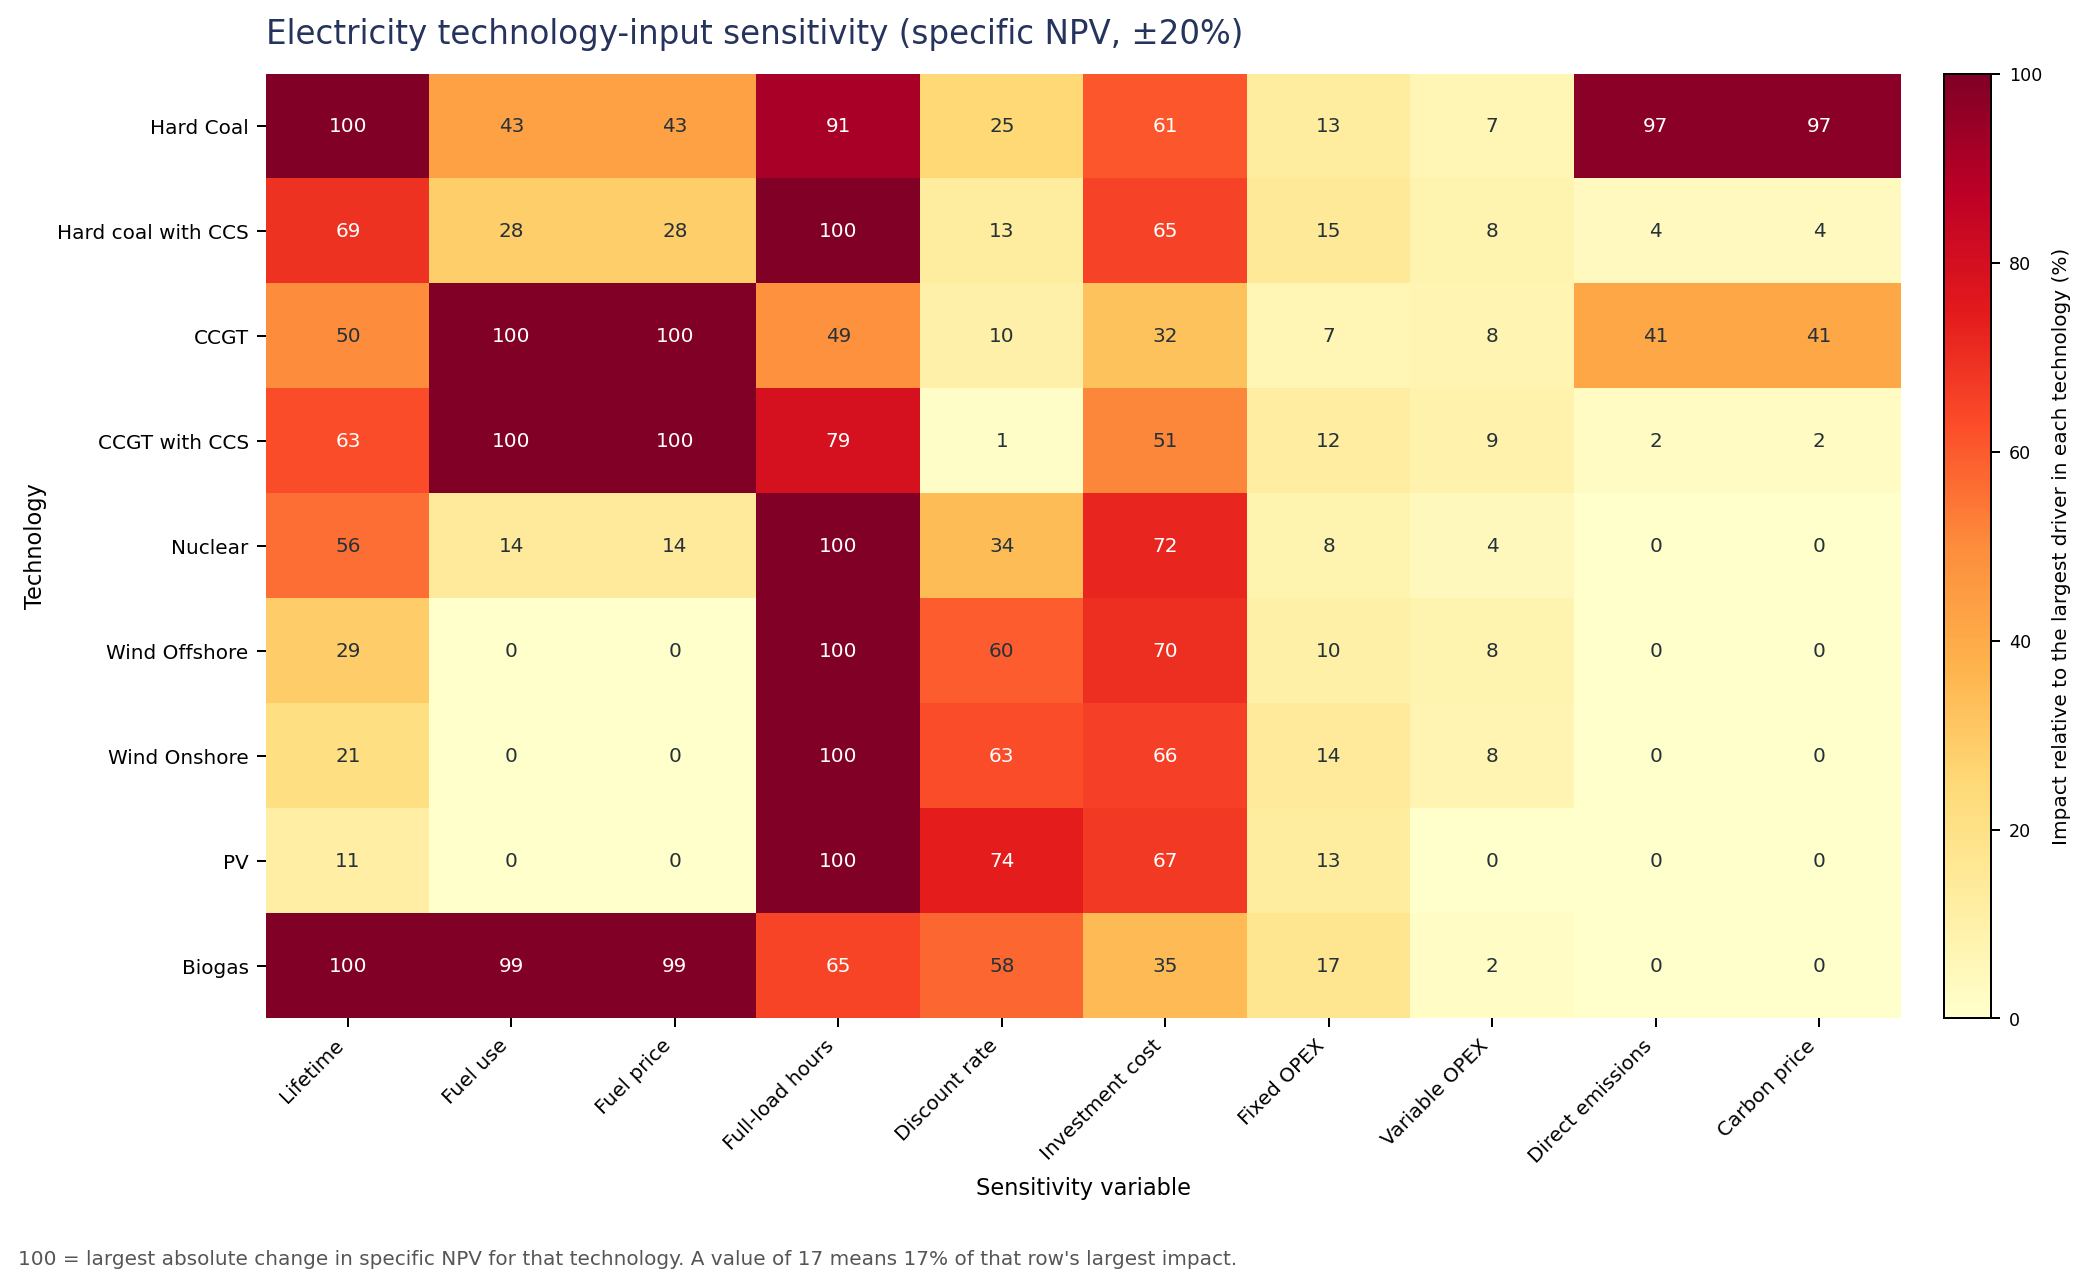

In [4]:
for sector in SECTORS:
    fig = build_sensitivity_heatmap_figure(
        standardized=sensitivity,
        sector=sector,
        variation_fraction=VARIATION_FRACTION,
        metric=NPV_METRIC,
    )
    plt.show()
    plt.close(fig)

## Optional output files

Set `SAVE_OUTPUTS = True` in the settings cell to write one CSV to `data/processed/` and one heatmap PNG per selected sector to `figures/`.

In [5]:
if SAVE_OUTPUTS:
    prefix = date.today().isoformat()
    metric_suffix = "Specific" if NPV_METRIC == METRIC_SPECIFIC else "Total"
    variation_suffix = f"{VARIATION_FRACTION * 100:g}".replace(".", "p") + "pct"

    processed_dir = PROJECT_ROOT / "data" / "processed"
    processed_dir.mkdir(parents=True, exist_ok=True)
    csv_path = processed_dir / f"{prefix}-Sensitivity_standardized_{metric_suffix}_{variation_suffix}.csv"
    sensitivity.to_csv(csv_path, index=False)

    saved_paths = [csv_path]
    for sector in SECTORS:
        output_path = PROJECT_ROOT / "figures" / (
            f"{prefix}-Sensitivity_Heatmap_Standardized_{metric_suffix}_{variation_suffix}_{sector.title()}.png"
        )
        saved_paths.append(
            plot_sensitivity_heatmap(
                standardized=sensitivity,
                sector=sector,
                variation_fraction=VARIATION_FRACTION,
                output_path=output_path,
                metric=NPV_METRIC,
            )
        )

    for path in saved_paths:
        print(path.relative_to(PROJECT_ROOT))
else:
    print("SAVE_OUTPUTS is False; no files were written.")

SAVE_OUTPUTS is False; no files were written.
